In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import os
from pathlib import Path

In [2]:
Path.cwd().parent.parent / "data" / "Telco-Customer-Churn.csv"

WindowsPath('e:/learn/bits_pliani_1/sem_2/api_drive_cloud_native_solutions/bits_sem2_api_driven_cloud_native_assignment_1/data/Telco-Customer-Churn.csv')

In [3]:
file_path = Path.cwd().parent.parent / "data" / "Telco-Customer-Churn.csv"
print(file_path)
data = pd.read_csv(file_path)

e:\learn\bits_pliani_1\sem_2\api_drive_cloud_native_solutions\bits_sem2_api_driven_cloud_native_assignment_1\data\Telco-Customer-Churn.csv


In [13]:
'''
Basic Stats
1. Check for null values and empty spaces
2. check for data types.
3. Descriptive stats - not as of now.
'''

'\nBasic Stats\n1. Check for null values and empty spaces\n2. check for data types.\n3. Descriptive stats - not as of now.\n'

In [14]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# check null values
data.isnull().sum()  # No null values.

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
# Check for cells that are just whitespace
# This returns True if the cell is empty or only contains spaces
is_empty_space = data.apply(lambda x: x.astype(str).str.strip() == "").any()

print("Columns with empty strings/spaces:")
print(is_empty_space[is_empty_space == True])

# Fill empty space with null value
data[is_empty_space[is_empty_space == True].index[0]] = data[is_empty_space[is_empty_space == True].index[0]].apply(lambda x: np.nan if x.strip() == "" else x )

Columns with empty strings/spaces:
TotalCharges    True
dtype: bool


In [17]:
is_empty_space[is_empty_space == True].index[0]

'TotalCharges'

In [18]:
# data['TotalCharges']

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
col = 'OnlineSecurity'
data[col].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [9]:
'''
data types
----------
 0   customerID        - String - to be dropped
 1   gender            - String - boolean
 2   SeniorCitizen     - integer
 3   Partner           - String - boolean
 4   Dependents        - String - boolean
 5   tenure            - integer - discrete - binning
 6   PhoneService      - string - boolean
 7   MultipleLines     - string - Label encoding 
 8   InternetService   - string - Label encoding
 9   OnlineSecurity    - string - Label encoding
 10  OnlineBackup      - string - Label encoding
 11  DeviceProtection  - string - Label encoding
 12  TechSupport       - string - Label encoding
 13  StreamingTV       - string - Label encoding
 14  StreamingMovies   - string - Label encoding
 15  Contract          - string - Label encoding
 16  PaperlessBilling  - string - boolean 
 17  PaymentMethod     - string - Label encoding
 18  MonthlyCharges    - float [continous] - standardize - binning
 19  TotalCharges      - string - float [continous] - standardize - binning
 
 Target
 ------
 20  Churn             - string - boolean - target
'''

'\ndata types\n----------\n 0   customerID        - String - to be dropped\n 1   gender            - String - boolean\n 2   SeniorCitizen     - integer\n 3   Partner           - String - boolean\n 4   Dependents        - String - boolean\n 5   tenure            - integer - discrete - binning\n 6   PhoneService      - string - boolean\n 7   MultipleLines     - string - Label encoding \n 8   InternetService   - string - Label encoding\n 9   OnlineSecurity    - string - Label encoding\n 10  OnlineBackup      - string - Label encoding\n 11  DeviceProtection  - string - Label encoding\n 12  TechSupport       - string - Label encoding\n 13  StreamingTV       - string - Label encoding\n 14  StreamingMovies   - string - Label encoding\n 15  Contract          - string - Label encoding\n 16  PaperlessBilling  - string - boolean \n 17  PaymentMethod     - string - Label encoding\n 18  MonthlyCharges    - float [continous] - standardize - binning\n 19  TotalCharges      - string - float [continous

In [27]:
'''
1. One hot encoding and Label Encoding
3. Binning
4. Standardize - Normalize
'''

'\n1. One hot encoding and Label Encoding\n3. Binning\n4. Standardize - Normalize\n'

In [28]:
# Binning --------
data['TotalCharges']= data['TotalCharges'].astype(float)
# Divide data into 3 equal-sized groups (Quartiles)
data['MonthlyCharges_bin'] = pd.qcut(data['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])
data['TotalCharges_bin'] = pd.qcut(data['TotalCharges'], q=3, labels=['Low', 'Medium', 'High'])
data['tenure_bin'] = pd.qcut(data['tenure'], q=3, labels=['Low', 'Medium', 'High'])

In [29]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'MonthlyCharges_bin', 'TotalCharges_bin', 'tenure_bin'],
      dtype='object')

In [32]:
## Encoding --------------
# Select your columns
bool_cols_to_encode = ['gender', 'Partner', 'Dependents', 'PhoneService',  'PaperlessBilling', 'Churn' ]

# Multi level columns
multi_level_cols_to_encode = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                  'PaperlessBilling', 'PaymentMethod']

# bin_cols = ['']

cols_to_encode= bool_cols_to_encode + multi_level_cols_to_encode

# Initialize the encoder
encoder = OrdinalEncoder()

# Fit and transform in one go
data[cols_to_encode] = encoder.fit_transform(data[cols_to_encode]).astype(int)

data[cols_to_encode].head()


,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,1,0,0,1,0,1,0,0,2,0,0,0,0,0,1,2
1,1,0,0,1,0,0,0,0,2,0,2,0,0,0,1,0,3
2,1,0,0,1,1,1,0,0,2,2,0,0,0,0,0,1,3
3,1,0,0,0,0,0,1,0,2,0,2,2,0,0,1,0,0
4,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,1,2


In [31]:
data['OnlineBackup'].value_counts()

OnlineBackup
0    3088
2    2429
1    1526
Name: count, dtype: int64

In [33]:
#### Standardization --------------------
cols_to_be_normlaized = ['MonthlyCharges', 'TotalCharges', 'tenure']
data['TotalCharges']= data['TotalCharges'].astype(float)

## x - min / (max -min)
# Vectorized operation across the subset
data[cols_to_be_normlaized] = (data[cols_to_be_normlaized] - data[cols_to_be_normlaized].min()) / (data[cols_to_be_normlaized].max() - data[cols_to_be_normlaized].min())
data[cols_to_be_normlaized]


,MonthlyCharges,TotalCharges,tenure
0,0.115423,0.001275,0.013889
1,0.385075,0.215867,0.472222
2,0.354229,0.010310,0.027778
3,0.239303,0.210241,0.625000
4,0.521891,0.015330,0.027778
...,...,...,...
7038,0.662189,0.227521,0.333333
7039,0.845274,0.847461,1.000000
7040,0.112935,0.037809,0.152778
7041,0.558706,0.033210,0.055556


In [34]:
import pandas as pd
from pathlib import Path
path = Path.cwd().parent.parent / "data" / "preprocessed_data.csv"
data = pd.read_csv(path)

In [35]:
data[['tenure', 'TotalCharges']].corr()

,tenure,TotalCharges
tenure,1.000000,0.826178
TotalCharges,0.826178,1.000000


<Axes: >

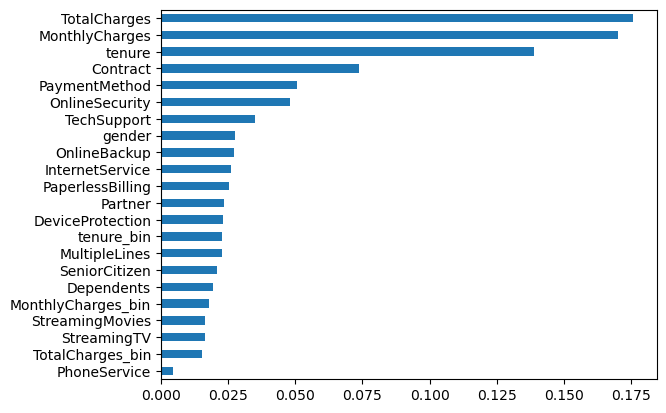

In [36]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop('Churn', axis=1)
y = data['Churn']

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)
importance.sort_values().plot(kind='barh')

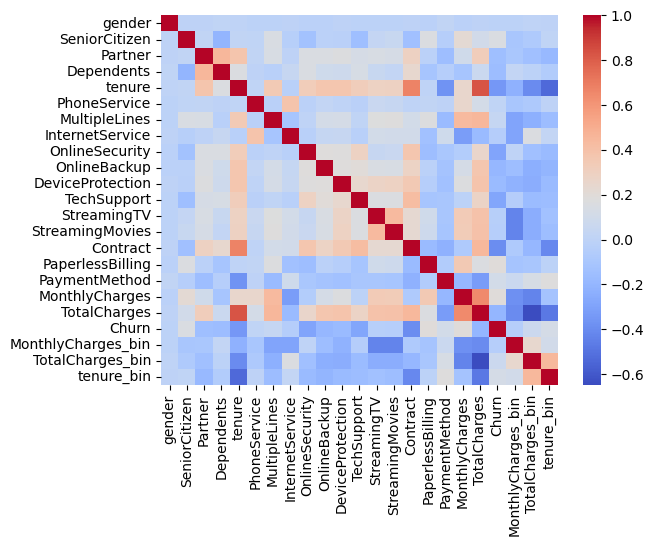

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = data.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()
# sns.heatmap(data, annot=True)  # annot=True shows values
# plt.show()

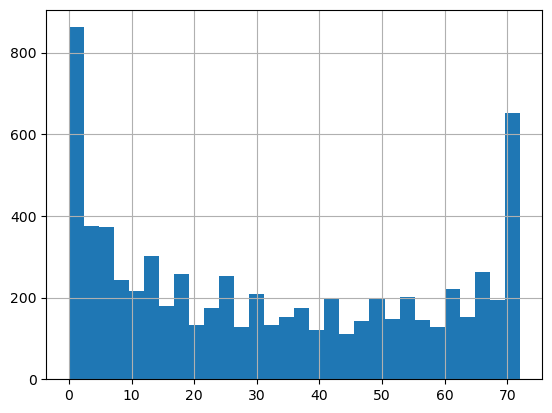

In [38]:
path = Path.cwd().parent.parent / "data" / "Telco-Customer-Churn.csv"
data = pd.read_csv(path)
data['tenure'].hist(bins=30)
plt.show()

In [ ]:
# Replace these variables with your actual Prefect Cloud credentials
PREFECT_API_KEY = "pnu_9ExUd6v7xvk7bG8AZ64dcfLx8qy7b40okpbv"  # Your Prefect Cloud API key
ACCOUNT_ID = 'bed1093b-fa82-493b-9836-ced3bc9978a0'  # Your Prefect Cloud Account ID
WORKSPACE_ID = 'cfb6292c-cae3-47c1-87ed-f8a0ab9388b9'  # Your Prefect Cloud Workspace ID
DEPLOYMENT_ID = "d8c1eaff-e5e2-4e0b-ab03-67f276850392"  # workflow.py deployment

URL = 'https://api.prefect.cloud/api/accounts/bed1093b-fa82-493b-9836-ced3bc9978a0/workspaces/cfb6292c-cae3-47c1-87ed-f8a0ab9388b9'

PREFECT_API_KEY = 'pnu_xb7ZOvS6xHzx2B2wDIGlkQUoUuMskZ4r0X9s'